# Notebook 5: Phase 3b - Commercial Species Validation

**Sequential Transfer Learning for Medicinal Plant Identification**

---

## Purpose

Fine-tune on Dataset 5 (SIMPD - South Indian Medicinal Plants) for commercial
species validation. This is the **final training phase** and validates
cross-regional generalization (Bangladesh -> South India).

**Dataset 5 Info:**
- 20 species from South India (Tirunelveli region)
- ~2,503 images
- Source: SIMPD V1 dataset (Mendeley Data)

```
Phase 1: General Features (Dataset 1)        DONE
    |
Phase 2: Regional Context (Dataset 2)         DONE
    |
Phase 3a: Endangered Species (Dataset 4)      DONE
    |
Phase 3b: Commercial Species (Dataset 5)  <-- WE ARE HERE (FINAL)
```

---

## KEY: Complete Sequential Transfer Chain

The model now carries knowledge from:
- ImageNet (general visual features)
- Dataset 1 (general medicinal plant features)
- Dataset 2 (Bangladesh regional features)
- Dataset 4 (endangered species features)

**Target: Commercial species precision >= 95%**

High precision means: when the model says a plant is safe to harvest,
it is almost certainly correct. This protects farmers from accidentally
harvesting protected species.

---

**Prerequisites:**
- Run notebooks 01, 02, 03, 04 first
- `models/phase3a_endangered.keras` must exist in Google Drive
- GPU required: Runtime -> Change runtime type -> GPU

## 1. Mount Google Drive & Setup

In [1]:
# Mount Google Drive
from google.colab import drive

print(">>> Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)
print(">>>>> Google Drive mounted!")

>>> Mounting Google Drive...
Mounted at /content/drive
>>>>> Google Drive mounted!


In [2]:
# Import libraries
import os
import json
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f">>> GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU! Go to Runtime -> Change runtime type -> GPU")

TensorFlow version: 2.19.0
>>> GPU detected: /physical_device:GPU:0


In [3]:
# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.00005  # very low LR for final fine-tuning stage
VALIDATION_SPLIT = 0.2
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Google Drive paths
DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")

# Phase 3a model path
PHASE3A_MODEL_PATH = os.path.join(MODEL_DIR, "phase3a_endangered.keras")

os.makedirs(MODEL_DIR, exist_ok=True)

print(">>> Configuration loaded")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Project: {PROJECT_DIR}")

>>> Configuration loaded
   Learning rate: 5e-05
   Project: /content/drive/MyDrive/MedicinalPlant_Dissertation


## 2. Load Phase 3a Model (Sequential Transfer)

We load the Phase 3a model which contains knowledge from:
- ImageNet -> Dataset 1 -> Dataset 2 -> Dataset 4

In [4]:
# Load Phase 3a model
if not os.path.exists(PHASE3A_MODEL_PATH):
    raise FileNotFoundError(
        f"Phase 3a model not found!\n"
        f"Expected: {PHASE3A_MODEL_PATH}\n\n"
        "Please run 04_phase3a_endangered.ipynb first!"
    )

print(f">>> Loading Phase 3a model from Google Drive...")
print(f"   {PHASE3A_MODEL_PATH}")

phase3a_model = keras.models.load_model(PHASE3A_MODEL_PATH)

print(f"\n>>>>> Phase 3a model loaded!")
print(f"   Layers: {len(phase3a_model.layers)}")
try:
    print(f"   Output classes: {phase3a_model.output_shape[-1]}")
except:
    pass

# Show layer names
print(f"\n   Model layers:")
for i, layer in enumerate(phase3a_model.layers):
    try:
        if hasattr(layer, 'output_shape'):
             print(f"     [{i}] {layer.name} - trainable: {layer.trainable} - output: {layer.output_shape}")
        else:
             print(f"     [{i}] {layer.name} - trainable: {layer.trainable}")
    except:
        print(f"     [{i}] {layer.name} - trainable: {layer.trainable}")

>>> Loading Phase 3a model from Google Drive...
   /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3a_endangered.keras

>>>>> Phase 3a model loaded!
   Layers: 12
   Output classes: 16

   Model layers:
     [0] augmentation_endangered - trainable: True - output: (None, 224, 224, 3)
     [1] resnet50 - trainable: True - output: (None, 7, 7, 2048)
     [2] global_average_pooling2d - trainable: True
     [3] batch_normalization - trainable: True
     [4] dropout - trainable: True
     [5] dense - trainable: True
     [6] batch_normalization_1 - trainable: True
     [7] dropout_1 - trainable: True
     [8] dense_1 - trainable: True
     [9] batch_normalization_2 - trainable: True
     [10] dropout_2 - trainable: True
     [11] dense_2 - trainable: True


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 98 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [5]:
# Extract the ResNet50 base with Phase 3a learned weights
resnet_base = None
for layer in phase3a_model.layers:
    if 'resnet' in layer.name.lower():
        resnet_base = layer
        break

if resnet_base is None:
    # fallback: look for large sub-model
    for layer in phase3a_model.layers:
        if hasattr(layer, 'layers') and len(layer.layers) > 10:
            resnet_base = layer
            break

if resnet_base is not None:
    print(f">>> Extracted ResNet50 base from Phase 3a")
    print(f"   Name: {resnet_base.name}")
    print(f"   This base carries: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a")
else:
    print("WARNING: Could not extract ResNet50 base. Will use fresh ImageNet weights.")

>>> Extracted ResNet50 base from Phase 3a
   Name: resnet50
   This base carries: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a


## 3. Find and Load Dataset 5 (SIMPD South India)

In [6]:
# Extract Dataset 5 if needed
import zipfile

zip_path = os.path.join(DATA_DIR, "dataset5.zip")
extract_dir = os.path.join(DATA_DIR, "dataset5")

if os.path.exists(extract_dir) and os.listdir(extract_dir):
    print(f">>>>> Dataset 5 already extracted - SKIPPING")
else:
    print(">>> Extracting dataset5.zip...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    # Handle nested zips
    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            if file.endswith('.zip'):
                nested = os.path.join(root, file)
                print(f"   Extracting nested: {file}")
                with zipfile.ZipFile(nested, 'r') as z:
                    z.extractall(root)
                os.remove(nested)
    print(">>>>> Dataset 5 extracted!")

>>> Extracting dataset5.zip...
>>>>> Dataset 5 extracted!


In [7]:
# Find image directory
def find_image_directory(base_dir):
    """Find the directory containing class folders with images."""
    if not os.path.exists(base_dir):
        return None
    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if not dirs:
            continue
        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
                           for f in sample_files)
            if has_images:
                return root
    return None

# Find Dataset 5
print(">>> Finding Dataset 5 (SIMPD South India)...")

config_path = os.path.join(PROJECT_DIR, "dataset_config.json")
DATASET5_PATH = None

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
    DATASET5_PATH = config.get("dataset_paths", {}).get("dataset5")

if not DATASET5_PATH or not os.path.exists(DATASET5_PATH):
    dataset5_base = os.path.join(DATA_DIR, "dataset5")
    DATASET5_PATH = find_image_directory(dataset5_base)

if DATASET5_PATH and os.path.exists(DATASET5_PATH):
    classes = sorted([d for d in os.listdir(DATASET5_PATH)
                      if os.path.isdir(os.path.join(DATASET5_PATH, d)) and not d.startswith('.')])
    print(f"\n>>>>> Dataset 5 found!")
    print(f"   Path: {DATASET5_PATH}")
    print(f"   Classes: {len(classes)}")
    print(f"   Species: {classes}")
else:
    raise FileNotFoundError("Dataset 5 not found! Run 01_data_exploration.ipynb first.")

>>> Finding Dataset 5 (SIMPD South India)...

>>>>> Dataset 5 found!
   Path: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset5/SIMPD V1 South Indian Medicinal Plants dataset (Version 1)
   Classes: 20
   Species: ['Abutilon Indicum', 'Aloe barbadensis miller', 'Calotropis gigantea', 'Canna indica', 'Cissus quadrangularis', 'Curcuma longa', 'Eclipta prostrate', 'Eichhornia Crassipes', 'Hibiscus Rosasinensis', 'Ixora coccinea', 'Justica adhatoda', 'Murraya koenigii', 'Ocimum tenuiflorum', 'Ouretlanata', 'Phyllanthus amarus', 'Ricinus communis', 'Senna Atriculata', 'Sesbania grandiflora', 'Trifolium Repens', 'Ziziphus mauritiana']


In [8]:
# Load Dataset 5
print(f">>> Loading Dataset 5 (SIMPD - {len(classes)} commercial species)...\n")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET5_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET5_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print(f">>>>> Dataset 5 loaded!")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Class names: {class_names}")

>>> Loading Dataset 5 (SIMPD - 20 commercial species)...

Found 2513 files belonging to 20 classes.
Using 2011 files for training.
Found 2513 files belonging to 20 classes.
Using 502 files for validation.
>>>>> Dataset 5 loaded!
   Classes: 20
   Class names: ['Abutilon Indicum', 'Aloe barbadensis miller', 'Calotropis gigantea', 'Canna indica', 'Cissus quadrangularis', 'Curcuma longa', 'Eclipta prostrate', 'Eichhornia Crassipes', 'Hibiscus Rosasinensis', 'Ixora coccinea', 'Justica adhatoda', 'Murraya koenigii', 'Ocimum tenuiflorum', 'Ouretlanata', 'Phyllanthus amarus', 'Ricinus communis', 'Senna Atriculata', 'Sesbania grandiflora', 'Trifolium Repens', 'Ziziphus mauritiana']


In [9]:
# Class distribution check
print("\nClass Distribution (Dataset 5 - Commercial):")
print("=" * 50)

class_counts = {}
for class_name in class_names:
    class_path = os.path.join(DATASET5_PATH, class_name)
    count = len([f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    class_counts[class_name] = count
    print(f"   {class_name}: {count} images")

total = sum(class_counts.values())
print(f"\n   Total: {total} images")


Class Distribution (Dataset 5 - Commercial):
   Abutilon Indicum: 165 images
   Aloe barbadensis miller: 145 images
   Calotropis gigantea: 106 images
   Canna indica: 149 images
   Cissus quadrangularis: 134 images
   Curcuma longa: 110 images
   Eclipta prostrate: 208 images
   Eichhornia Crassipes: 202 images
   Hibiscus Rosasinensis: 113 images
   Ixora coccinea: 114 images
   Justica adhatoda: 100 images
   Murraya koenigii: 118 images
   Ocimum tenuiflorum: 102 images
   Ouretlanata: 119 images
   Phyllanthus amarus: 111 images
   Ricinus communis: 109 images
   Senna Atriculata: 125 images
   Sesbania grandiflora: 91 images
   Trifolium Repens: 100 images
   Ziziphus mauritiana: 92 images

   Total: 2513 images


In [10]:
# Preprocessing
normalization = layers.Rescaling(1./255)  # scale to [0,1]
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(lambda x, y: (normalization(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization(x), y))

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print(">>> Datasets normalized and cached")

>>> Datasets normalized and cached


## 4. Build Phase 3b Model

We reuse the ResNet50 base from Phase 3a and build a new
classification head for 20 commercial species.

**Target: Precision >= 95% (minimize false positives)**

This also validates **cross-regional generalization**:
the model was trained on Bangladesh data (Phases 1-3a),
now we test on South Indian data.

In [11]:
# Build Phase 3b model
print(">>> Building Phase 3b model (Commercial Species)...")
print("   Transfer chain: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a -> Phase 3b\n")

if resnet_base is not None:
    print("   Using Phase 3a ResNet50 base (full sequential transfer)")
    base = resnet_base
else:
    print("   WARNING: Using fresh ImageNet ResNet50")
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Partially unfreeze top layers
base.trainable = True
total_layers = len(base.layers)
fine_tune_from = total_layers - 20  # unfreeze last 20 layers

for layer in base.layers[:fine_tune_from]:
    layer.trainable = False

trainable_count = sum(1 for l in base.layers if l.trainable)
print(f"   Base layers: {total_layers}")
print(f"   Trainable layers: {trainable_count}")

# Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation_commercial")

# Build model
model = keras.Sequential([
    keras.Input(shape=(224, 224, 3)),
    data_augmentation,
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')  # output for 20 commercial species
], name="phase3b_commercial")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print(f"\n>>>>> Model built for {NUM_CLASSES} commercial species")
model.summary()

>>> Building Phase 3b model (Commercial Species)...
   Transfer chain: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a -> Phase 3b

   Using Phase 3a ResNet50 base (full sequential transfer)
   Base layers: 175
   Trainable layers: 20

>>>>> Model built for 20 commercial species


Model: "phase3b_commercial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_commercial         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,784,532 (94.55 MB)

 Trainable params: 10,122,516 (38.61 MB)

 Non-trainable params: 14,662,016 (55.93 MB)

## 5. Train Phase 3b

In [12]:
# Callbacks - monitor PRECISION for commercial species
MODEL_PATH = os.path.join(MODEL_DIR, "phase3b_commercial.keras")

callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_precision', mode='max',
                    save_best_only=True, verbose=1),  # save best precision model
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4,
                      min_lr=1e-7, verbose=1)
]

print(f">>> Model will be saved to Google Drive:")
print(f"   {MODEL_PATH}")
print(f"   Monitoring: val_precision (max) - prioritizing commercial species accuracy")

>>> Model will be saved to Google Drive:
   /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3b_commercial.keras
   Monitoring: val_precision (max) - prioritizing commercial species accuracy


In [13]:
# Train
print("\n" + "="*50)
print(">>>>> STARTING PHASE 3b TRAINING (COMMERCIAL SPECIES)")
print("="*50)
print(f"Dataset: Dataset 5 - SIMPD ({NUM_CLASSES} species, South India)")
print(f"Transfer: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a -> Phase 3b")
print(f"Cross-regional: Bangladesh trained model -> South Indian data")
print("="*50 + "\n")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*50)
print(">>>>> PHASE 3b TRAINING COMPLETE!")
print("="*50)


>>>>> STARTING PHASE 3b TRAINING (COMMERCIAL SPECIES)
Dataset: Dataset 5 - SIMPD (20 species, South India)
Transfer: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a -> Phase 3b
Cross-regional: Bangladesh trained model -> South Indian data

Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1469 - loss: 3.2875 - precision: 0.3217 - recall: 0.0540
Epoch 1: val_precision improved from -inf to 0.78378, saving model to /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3b_commercial.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.1478 - loss: 3.2815 - precision: 0.3230 - recall: 0.0544 - val_accuracy: 0.1394 - val_loss: 2.7006 - val_precision: 0.7838 - val_recall: 0.0578 - learning_rate: 5.0000e-05
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.2888 - loss: 2.4991 - precision: 0.5045 - recall: 0.1413
Epoch 2: val_precision improved from 0.78378 to 0.86275, saving model to /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3b_com

## 6. Results & Evaluation

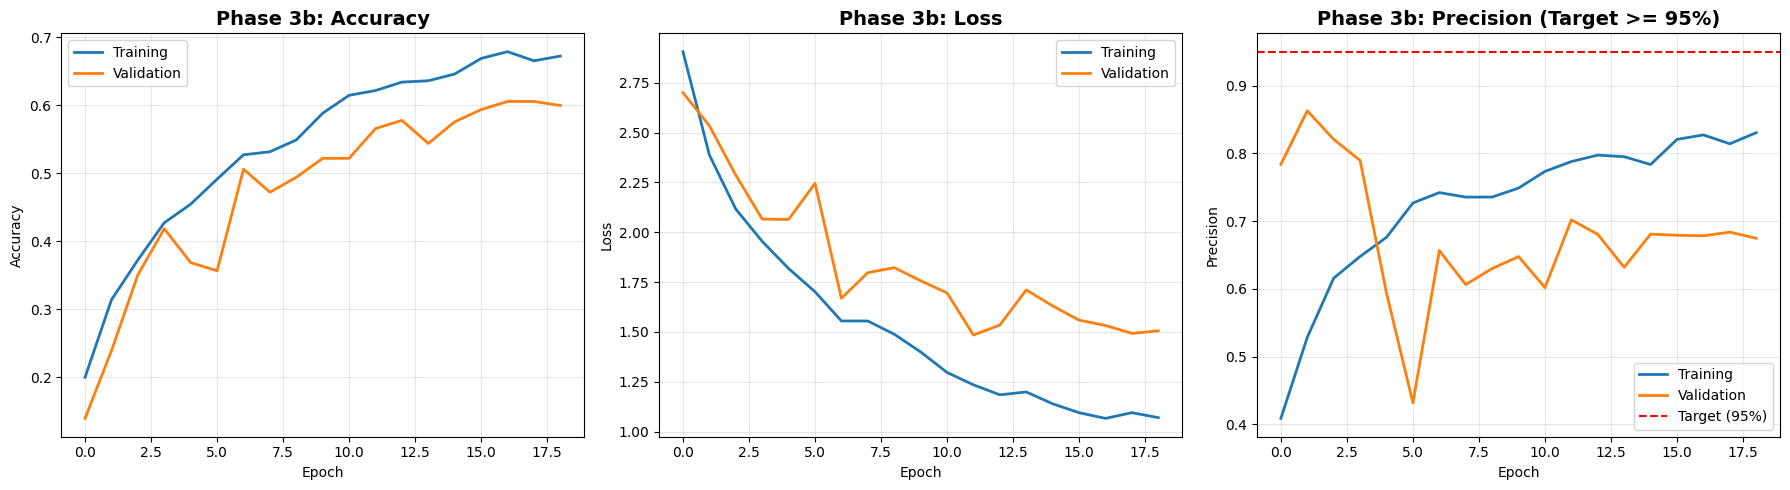

In [14]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Phase 3b: Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Phase 3b: Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Precision (key metric for commercial species)
axes[2].plot(history.history['precision'], label='Training', linewidth=2)
axes[2].plot(history.history['val_precision'], label='Validation', linewidth=2)
axes[2].axhline(y=0.95, color='r', linestyle='--', label='Target (95%)')
axes[2].set_title('Phase 3b: Precision (Target >= 95%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Precision')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'phase3b_training_curves.png'), dpi=150)
plt.show()

In [15]:
# Detailed evaluation
# Re-compile to ensure metrics are named correctly in Keras 3
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

val_results = model.evaluate(val_dataset, verbose=0)

print(">>> Phase 3b Results (Commercial Species)")
print("=" * 50)

metric_map = {}
# If names are still generic (keras 3 issue), map manually based on known compile order
# Order is typically: [loss, accuracy, precision, recall]
if len(val_results) == 4 and 'accuracy' not in model.metrics_names:
    print("   (Applying manual metric names due to Keras version)")
    manual_names = ['loss', 'accuracy', 'precision', 'recall']
    for name, value in zip(manual_names, val_results):
        print(f"   {name}: {value:.4f}")
        metric_map[name] = value
else:
    for name, value in zip(model.metrics_names, val_results):
        print(f"   {name}: {value:.4f}")
        metric_map[name] = value
print("=" * 50)

# Check against precision target
# Prefer 'val_precision' from history if evaluate fails to provide name
if 'precision' in metric_map:
    val_precision = metric_map['precision']
elif 'val_precision' in history.history:
    val_precision = history.history['val_precision'][-1]
    print(f"   (Using last validation precision from history: {val_precision:.4f})")
else:
    val_precision = 0.0

if val_precision > 0:
    if val_precision >= 0.95:
        print(f"\n   PRECISION TARGET MET: {val_precision*100:.1f}% >= 95%")
    else:
        print(f"\n   PRECISION BELOW TARGET: {val_precision*100:.1f}% < 95%")
        print(f"   Gap: {(0.95 - val_precision)*100:.1f} percentage points")
else:
    print("\nWARNING: Precision metric not found.")

>>> Phase 3b Results (Commercial Species)
   (Applying manual metric names due to Keras version)
   loss: 1.4843
   accuracy: 0.5657
   precision: 0.7018
   recall: 0.4781

   PRECISION BELOW TARGET: 70.2% < 95%
   Gap: 24.8 percentage points


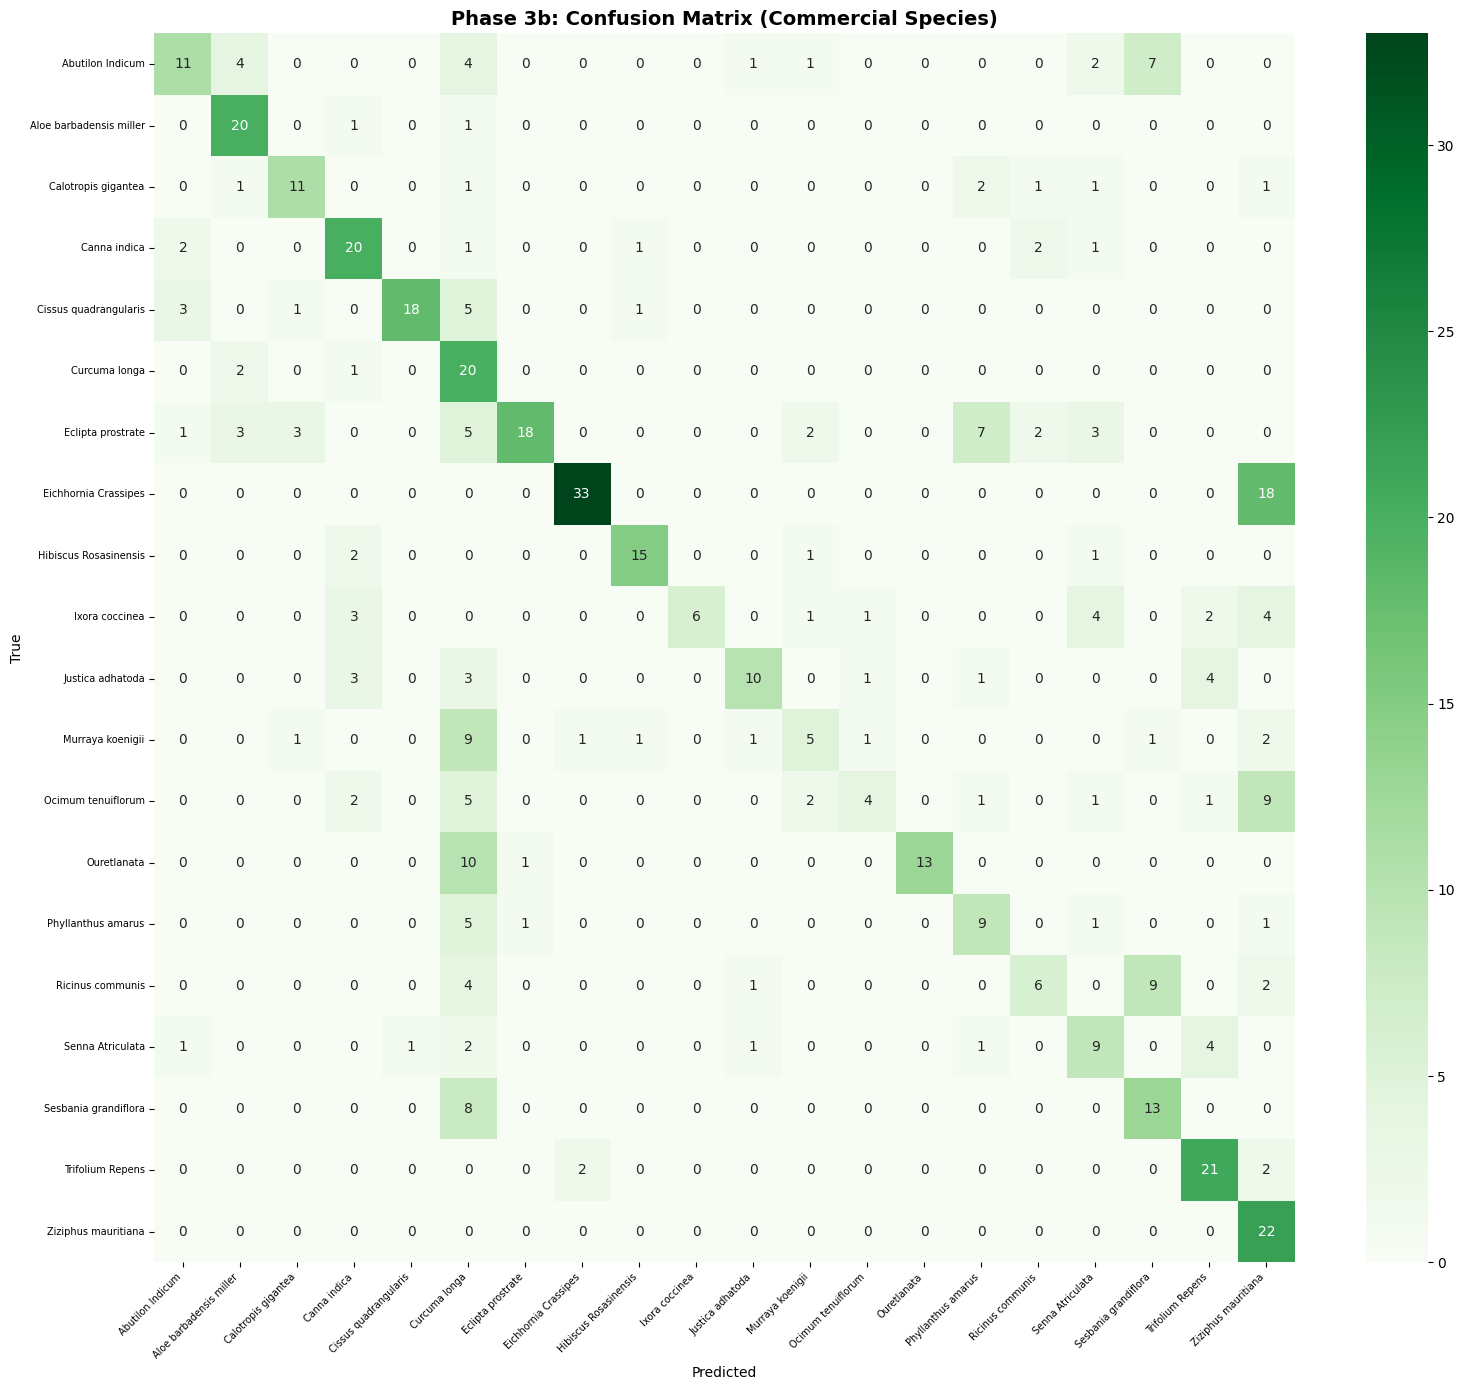

In [16]:
# Confusion matrix
y_true, y_pred, y_probs = [], [], []
for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))
    y_probs.extend(np.max(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Phase 3b: Confusion Matrix (Commercial Species)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'phase3b_confusion_matrix.png'), dpi=150)
plt.show()

In [17]:
# Per-species classification report
print("Per-Species Classification Report (Commercial)")
print("=" * 70)

# Calculate unique classes found in predictions
unique_labels = sorted(list(set(y_true) | set(y_pred)))
print(f"Classes present in validation set: {len(unique_labels)} / {len(class_names)}")

# Use labels parameter to force all classes to be reported (even if missing)
# Zero_division=0 handles classes with no samples
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    labels=range(len(class_names)),
    digits=3,
    zero_division=0
)
print(report)

# Highlight species with low precision
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    labels=range(len(class_names)),
    output_dict=True,
    zero_division=0
)

print("\n--- COMMERCIAL SPECIES PRECISION CHECK ---")
for species in class_names:
    if species in report_dict:
        prec_val = report_dict[species]['precision']
        support = report_dict[species]['support']

        status = "PASS" if prec_val >= 0.95 else "NEEDS ATTENTION"
        if support == 0:
            status = "NO DATA (Skipped)"

        print(f"   {species}: {prec_val*100:.1f}% precision (n={support}) [{status}]")

Per-Species Classification Report (Commercial)
Classes present in validation set: 20 / 20
                         precision    recall  f1-score   support

       Abutilon Indicum      0.611     0.367     0.458        30
Aloe barbadensis miller      0.667     0.909     0.769        22
    Calotropis gigantea      0.688     0.611     0.647        18
           Canna indica      0.625     0.741     0.678        27
  Cissus quadrangularis      0.947     0.643     0.766        28
          Curcuma longa      0.241     0.870     0.377        23
      Eclipta prostrate      0.900     0.409     0.562        44
   Eichhornia Crassipes      0.917     0.647     0.759        51
  Hibiscus Rosasinensis      0.833     0.789     0.811        19
         Ixora coccinea      1.000     0.286     0.444        21
       Justica adhatoda      0.714     0.455     0.556        22
       Murraya koenigii      0.417     0.227     0.294        22
     Ocimum tenuiflorum      0.571     0.160     0.250        25

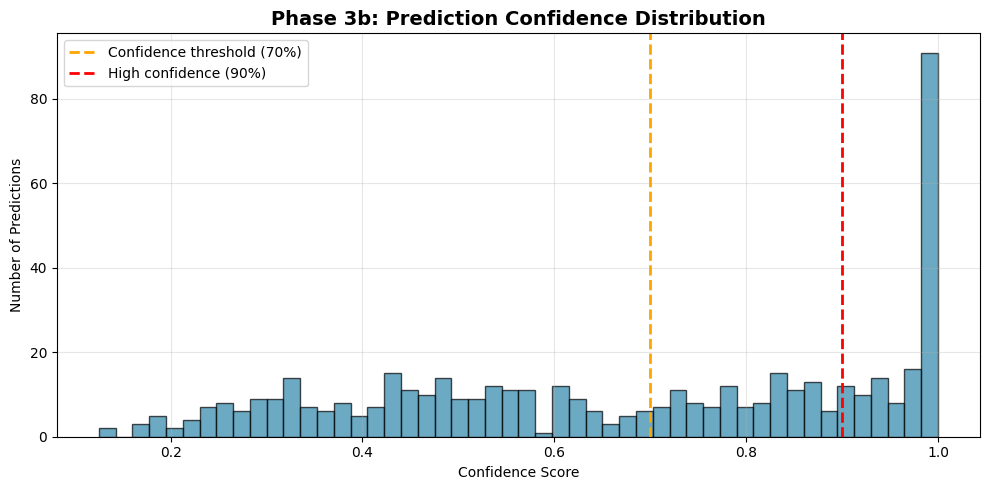


Confidence Statistics:
   Mean: 67.7%
   Median: 71.7%
   Below 70%: 244 predictions (48.6%)
   Above 90%: 147 predictions (29.3%)


In [18]:
# Confidence distribution (for the web app later)
plt.figure(figsize=(10, 5))
plt.hist(y_probs, bins=50, edgecolor='black', alpha=0.7, color='#2E86AB')
plt.axvline(x=0.7, color='orange', linestyle='--', linewidth=2, label='Confidence threshold (70%)')
plt.axvline(x=0.9, color='red', linestyle='--', linewidth=2, label='High confidence (90%)')
plt.title('Phase 3b: Prediction Confidence Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Confidence Score')
plt.ylabel('Number of Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'phase3b_confidence_distribution.png'), dpi=150)
plt.show()

# Stats
y_probs_arr = np.array(y_probs)
print(f"\nConfidence Statistics:")
print(f"   Mean: {np.mean(y_probs_arr)*100:.1f}%")
print(f"   Median: {np.median(y_probs_arr)*100:.1f}%")
print(f"   Below 70%: {np.sum(y_probs_arr < 0.7)} predictions ({np.mean(y_probs_arr < 0.7)*100:.1f}%)")
print(f"   Above 90%: {np.sum(y_probs_arr >= 0.9)} predictions ({np.mean(y_probs_arr >= 0.9)*100:.1f}%)")

## 7. Save Model & Export for Web App

In [19]:
# Save model
model.save(MODEL_PATH)
print(f">>>>> Model saved: {MODEL_PATH}")

# Also save as .h5 for the Flask web app
H5_PATH = os.path.join(MODEL_DIR, "phase3b_commercial.h5")
model.save(H5_PATH)
print(f">>>>> H5 model saved: {H5_PATH}")

# Save class names
with open(os.path.join(MODEL_DIR, "phase3b_class_names.json"), 'w') as f:
    json.dump(class_names, f)

# Save training history
with open(os.path.join(MODEL_DIR, "phase3b_history.json"), 'w') as f:
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    json.dump(history_dict, f)

# Save per-species metrics
with open(os.path.join(MODEL_DIR, "phase3b_species_metrics.json"), 'w') as f:
    json.dump(report_dict, f, indent=2)

# Update config
config_path = os.path.join(PROJECT_DIR, "dataset_config.json")
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
else:
    config = {"dataset_paths": {}}

config["dataset_paths"]["dataset5"] = DATASET5_PATH
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print("\n>>>>> All Phase 3b artifacts saved to Google Drive")

>>>>> Model saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3b_commercial.keras
>>>>> H5 model saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3b_commercial.h5

>>>>> All Phase 3b artifacts saved to Google Drive


## 8. Complete Sequential Transfer Learning Summary

### ALL 4 PHASES COMPLETE!

```
ImageNet
   |-> Phase 1: Dataset 1 (6 general species)
       |-> Phase 2: Dataset 2 (6 Bangladesh species)
           |-> Phase 3a: Dataset 4 (16 endangered species)
               |-> Phase 3b: Dataset 5 (20 commercial species)
```

### Files Saved to Google Drive:
- `models/phase1_baseline.keras`
- `models/phase2_regional.keras`
- `models/phase3a_endangered.keras`
- `models/phase3b_commercial.keras` + `.h5`
- Training curves, confusion matrices, species metrics for all phases

### Next Steps:
1. **Download `phase3b_commercial.h5`** from Google Drive to your local machine
2. **Download class names JSON files** for all phases
3. Place them in the `webapp/models/` folder
4. Run the Flask web application locally

In [20]:
print("\n" + "="*60)
print(">>>>> ALL TRAINING PHASES COMPLETE!")
print("="*60)
print(f"\nPhase 3b Results:")
print(f"   Accuracy: {max(history.history['val_accuracy'])*100:.1f}%")
print(f"   Best Precision: {max(history.history['val_precision'])*100:.1f}%")
print(f"   Species: {NUM_CLASSES} commercial species")
print(f"\nFull transfer chain: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a -> Phase 3b")
print(f"Cross-regional: Bangladesh trained -> South India tested")
print(f"\nModels saved: {MODEL_DIR}")
print(f"\n--- NEXT: Build the web application! ---")
print(f"Download phase3b_commercial.h5 and class_names JSONs to your local machine.")


>>>>> ALL TRAINING PHASES COMPLETE!

Phase 3b Results:
   Accuracy: 60.6%
   Best Precision: 86.3%
   Species: 20 commercial species

Full transfer chain: ImageNet -> Phase 1 -> Phase 2 -> Phase 3a -> Phase 3b
Cross-regional: Bangladesh trained -> South India tested

Models saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models

--- NEXT: Build the web application! ---
Download phase3b_commercial.h5 and class_names JSONs to your local machine.
